In [5]:
import pandas as pd

csv = "RAW_Datasets\\HF_lung_V1_RAW\\annotations.csv"
test = "RAW_Datasets\\HF_lung_V1_RAW\\test"
train = "RAW_Datasets\\HF_lung_V1_RAW\\train"

In [6]:
df = pd.read_csv(csv)
df.head()

,filename,split,label,start_time,end_time,duration
0,steth_20180814_09_37_11.wav,train,I,1.500,2.457,0.957
1,steth_20180814_09_37_11.wav,train,D,1.500,2.457,0.957
2,steth_20180814_09_37_11.wav,train,E,2.608,3.637,1.029
3,steth_20180814_09_37_11.wav,train,D,2.608,3.637,1.029
4,steth_20180814_09_37_11.wav,train,I,5.227,6.350,1.123


In [7]:
for col in ["label"]:
    print(df[col].value_counts())

label
I          34095
E          18349
D          15606
Wheeze      8457
Rhonchi     4740
Stridor      686
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81933 entries, 0 to 81932
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    81933 non-null  str    
 1   split       81933 non-null  str    
 2   label       81933 non-null  str    
 3   start_time  81933 non-null  float64
 4   end_time    81933 non-null  float64
 5   duration    81933 non-null  float64
dtypes: float64(3), str(3)
memory usage: 6.7 MB


In [8]:
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import warnings

# Suppress librosa warnings for cleaner output
warnings.filterwarnings('ignore')

# Define a color map so overlapping labels are easy to distinguish
COLOR_MAP = {
    'I': 'blue',
    'E': 'green',
    'D': 'red',
    'Wheeze': 'orange',
    'Rhonchi': 'purple',
    'Stridor': 'cyan'
}

In [ ]:
df = df[df["split"] == "train"]

,filename,split,label,start_time,end_time,duration
0,steth_20180814_09_37_11.wav,train,I,1.500,2.457,0.957
1,steth_20180814_09_37_11.wav,train,D,1.500,2.457,0.957
2,steth_20180814_09_37_11.wav,train,E,2.608,3.637,1.029
3,steth_20180814_09_37_11.wav,train,D,2.608,3.637,1.029
4,steth_20180814_09_37_11.wav,train,I,5.227,6.350,1.123
...,...,...,...,...,...,...
68077,trunc_2019-07-31-11-20-43-L8_8.wav,train,D,0.309,1.250,0.941
68078,trunc_2019-07-31-11-20-43-L8_8.wav,train,I,4.974,6.195,1.221
68079,trunc_2019-07-31-11-20-43-L8_8.wav,train,D,4.974,6.195,1.221
68080,trunc_2019-07-31-11-20-43-L8_8.wav,train,I,10.077,11.298,1.221


--- Analyzing Random File: steth_20190413_13_50_07.wav in 10.0s chunks ---


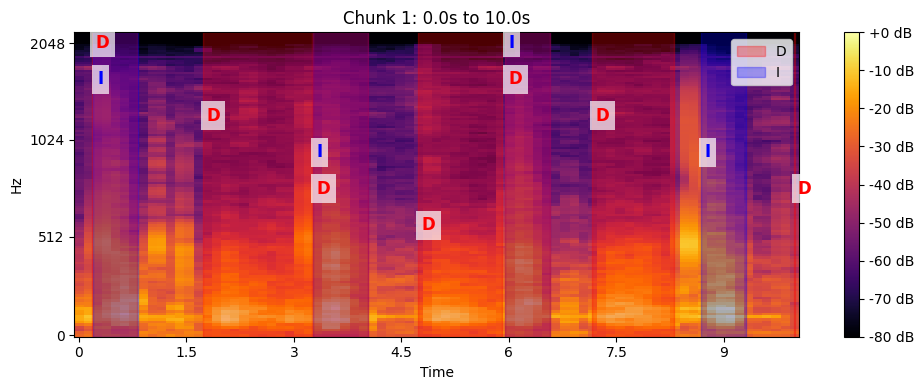

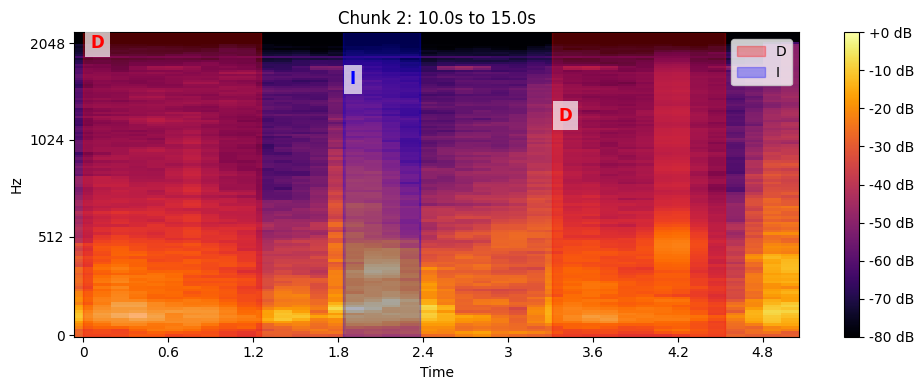

In [30]:
import random

# Configuration
CHUNK_LENGTH_SEC = 10.0  # 5 seconds per chunk
FMAX = 2200             # Lowered fmax to focus on clinical acoustic features

# Select one random file from the dataset
random_filename = random.choice(df['filename'].unique())
audio_path = os.path.join(train, random_filename)

print(f"--- Analyzing Random File: {random_filename} in {CHUNK_LENGTH_SEC}s chunks ---")

# Load the full audio
y, sr = librosa.load(audio_path, sr=None)
total_duration = librosa.get_duration(y=y, sr=sr)

# Get annotations for this specific file
file_annotations = df[df['filename'] == random_filename]

# Calculate the total number of chunks needed
num_chunks = int(np.ceil(total_duration / CHUNK_LENGTH_SEC))

for i in range(num_chunks):
    chunk_start = i * CHUNK_LENGTH_SEC
    chunk_end = min((i + 1) * CHUNK_LENGTH_SEC, total_duration)
    
    # Extract the audio slice for this chunk
    start_sample = int(chunk_start * sr)
    end_sample = int(chunk_end * sr)
    y_chunk = y[start_sample:end_sample]
    
    # Skip if the chunk is completely empty (can happen at the very end due to rounding)
    if len(y_chunk) == 0:
        continue
        
    # Compute Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y_chunk, sr=sr, n_mels=128, fmax=FMAX)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=FMAX, cmap='inferno')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Chunk {i+1}: {chunk_start:.1f}s to {chunk_end:.1f}s')
    
    height_offset = 0.95
    
    # Check all annotations to see if they fall into this time chunk
    for _, row in file_annotations.iterrows():
        lbl_start = row['start_time']
        lbl_end = row['end_time']
        lbl = row['label']
        
        # Condition: Does the annotation overlap with the current chunk's time window?
        if lbl_start < chunk_end and lbl_end > chunk_start:
            
            # Translate absolute time (from CSV) to relative time (for the chunk's x-axis)
            adjusted_start = max(0, lbl_start - chunk_start)
            adjusted_end = min(chunk_end - chunk_start, lbl_end - chunk_start)
            
            color = COLOR_MAP.get(lbl, 'white')
            
            # Draw semi-transparent block
            plt.axvspan(adjusted_start, adjusted_end, color=color, alpha=0.3, label=lbl)
            
            # Add text annotation
            plt.text(adjusted_start + 0.05, height_offset, lbl, color=color, fontsize=12, 
                     fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                     transform=plt.gca().get_xaxis_transform())
            
            # Stagger text heights
            height_offset -= 0.12
            if height_offset < 0.3:
                height_offset = 0.95
                
    # Clean up legend to avoid duplicate labels in the same chunk
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        plt.legend(by_label.values(), by_label.keys(), loc='upper right')
        
    plt.tight_layout()
    plt.show()

In [27]:
def plot_samples_for_label(target_label, n_samples=10):
    """
    Finds n_samples audio files containing the target_label, 
    computes the mel-spectrogram, and overlays ALL labels for those files.
    """
    print(f"--- Generating Spectrograms for files containing: {target_label} ---")
    
    # Get unique filenames that contain the target label
    valid_files = df[df['label'] == target_label]['filename'].unique()
    
    # Sample up to n_samples
    sampled_files = np.random.choice(valid_files, min(n_samples, len(valid_files)), replace=False)
    
    for filename in sampled_files:
        audio_path = os.path.join(train, filename)
        
        if not os.path.exists(audio_path):
            print(f"File not found: {audio_path}")
            continue
            
        # Load audio (sr=None preserves original sampling rate)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute Mel-spectrogram
        # n_fft and hop_length can be adjusted based on your specific audio characteristics
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=2048)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        # Plotting
        plt.figure(figsize=(14, 5))
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=2048, cmap='inferno')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Mel-Spectrogram: {filename}')
        
        # Get ALL annotations for this specific file
        file_annotations = df[df['filename'] == filename]
        
        # Track text heights so overlapping text annotations don't print on top of each other
        height_offset = 0.95
        
        for _, row in file_annotations.iterrows():
            start = row['start_time']
            end = row['end_time']
            lbl = row['label']
            color = COLOR_MAP.get(lbl, 'white')
            
            # Draw semi-transparent block for the duration
            plt.axvspan(start, end, color=color, alpha=0.2, label=lbl)
            
            # Add text annotation
            # We use axes fraction (transform=plt.gca().get_xaxis_transform()) so the text 
            # stays at the top of the plot regardless of the Mel frequency scale
            plt.text(start + 0.05, height_offset, lbl, color=color, fontsize=12, 
                     fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                     transform=plt.gca().get_xaxis_transform())
            
            # Stagger the height slightly for the next label in case they overlap in time
            height_offset -= 0.08
            if height_offset < 0.5: 
                height_offset = 0.95 
                
        # Remove duplicate labels in legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper right')
        
        plt.tight_layout()
        plt.show()

--- Generating Spectrograms for files containing: I ---


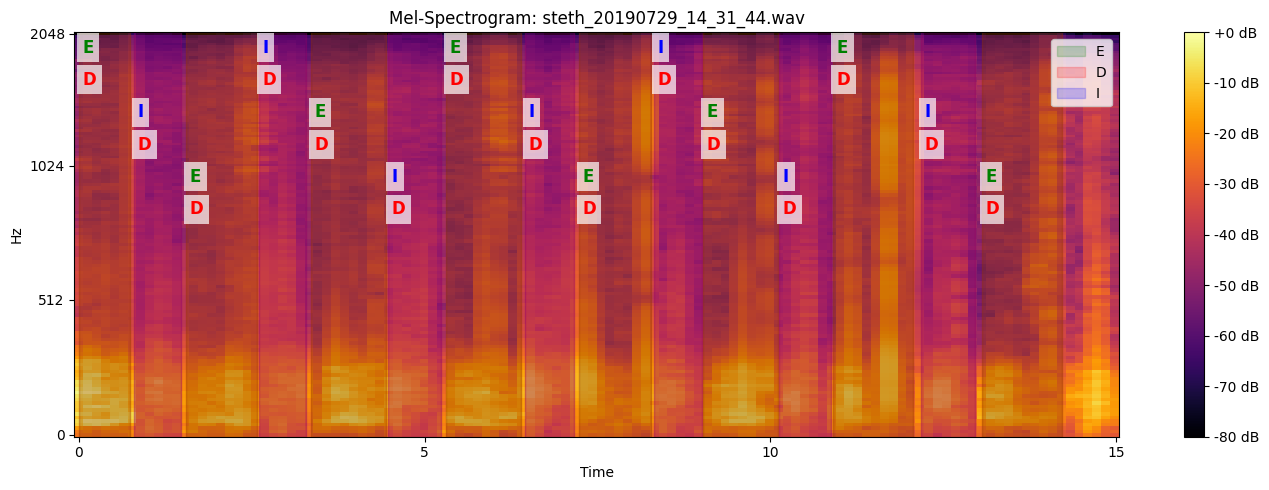

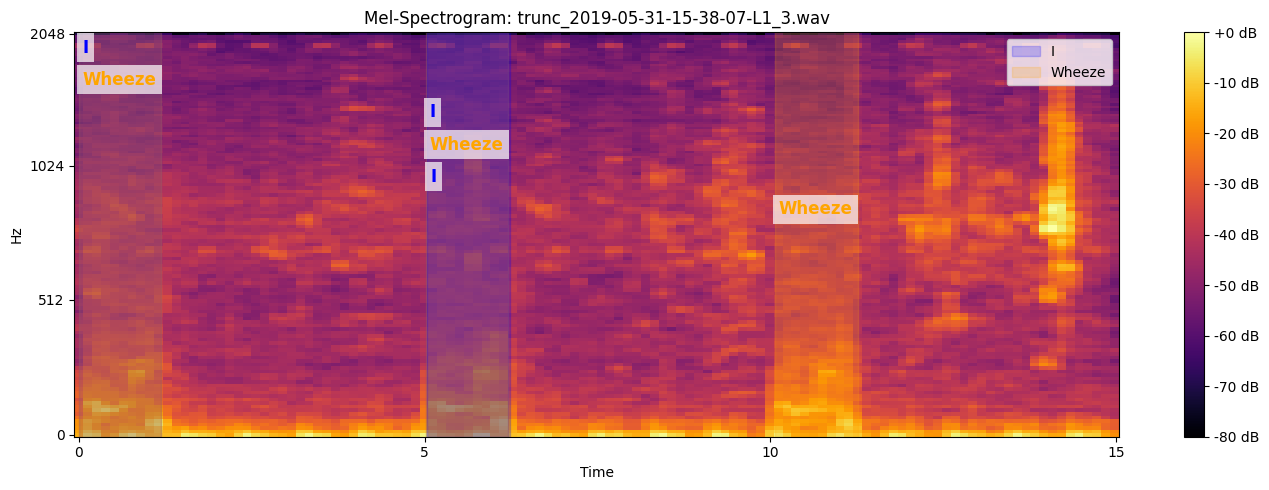

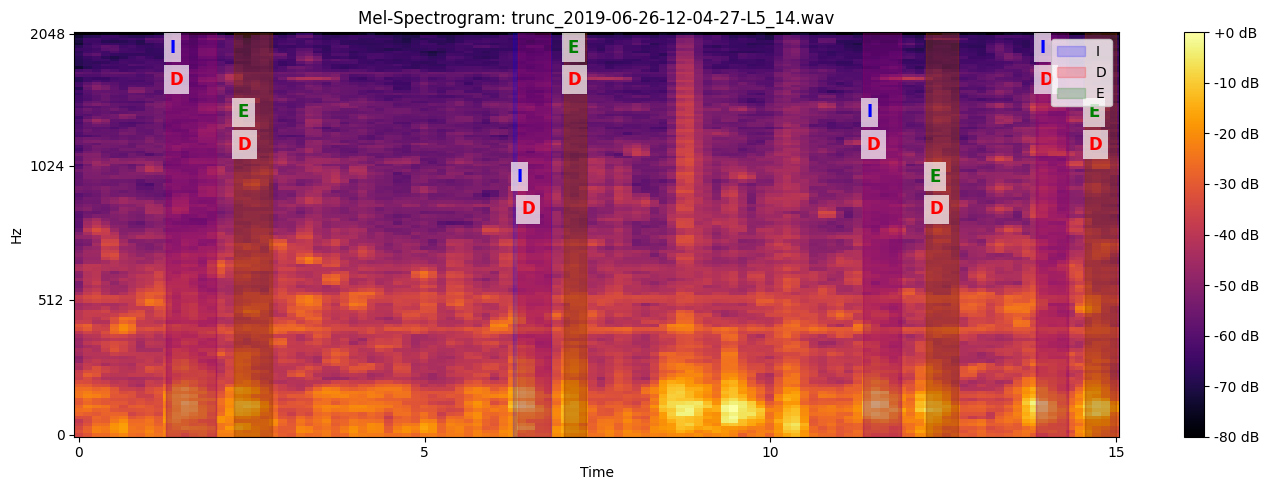

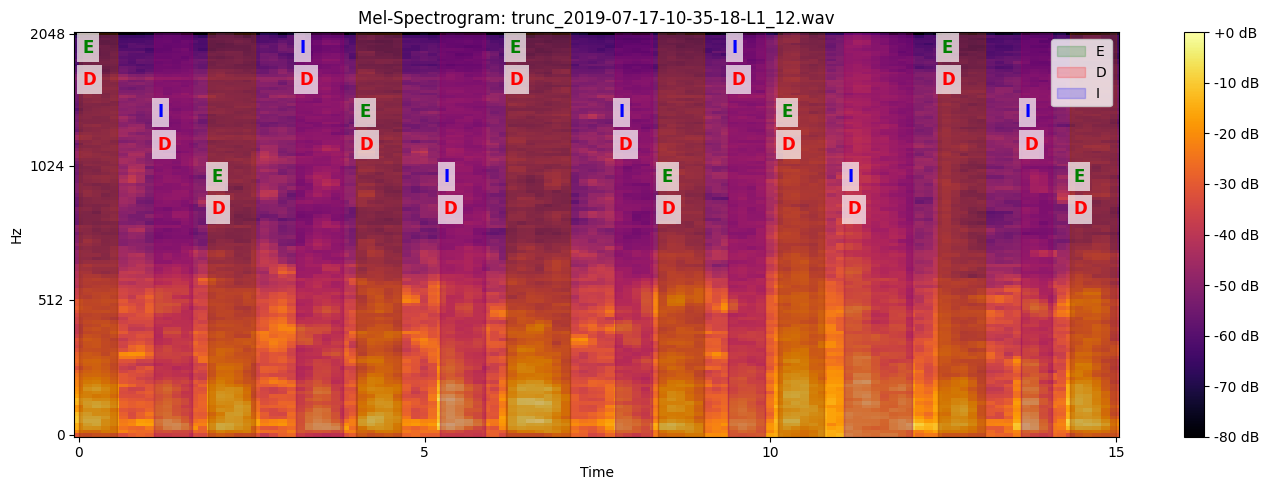

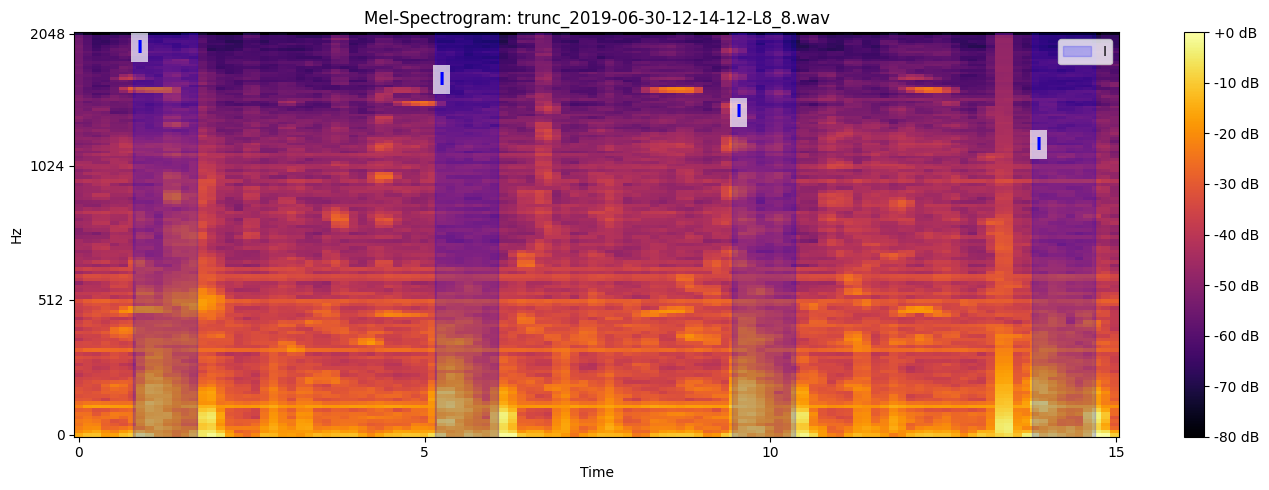

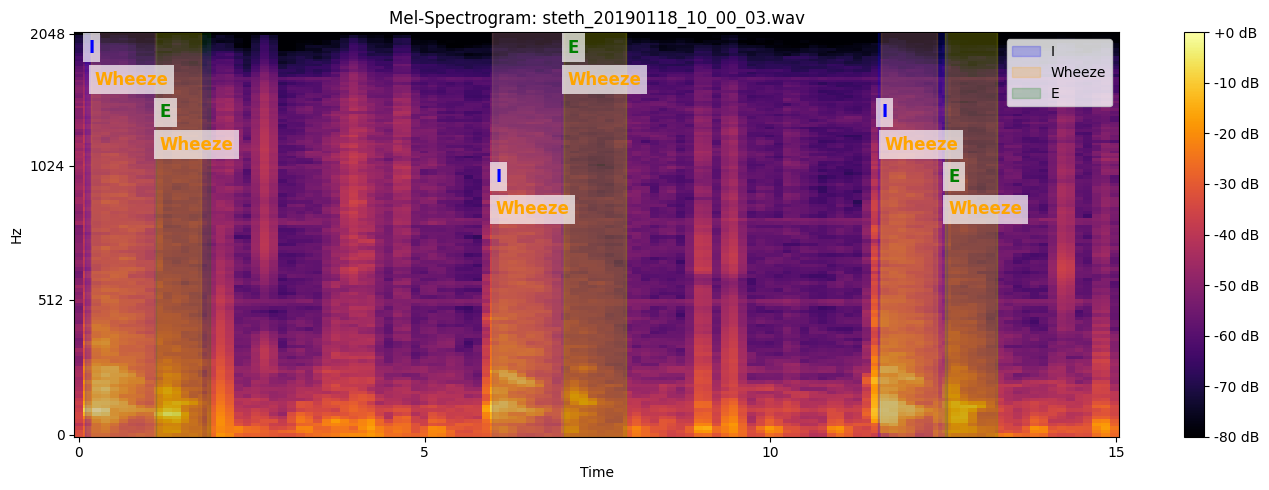

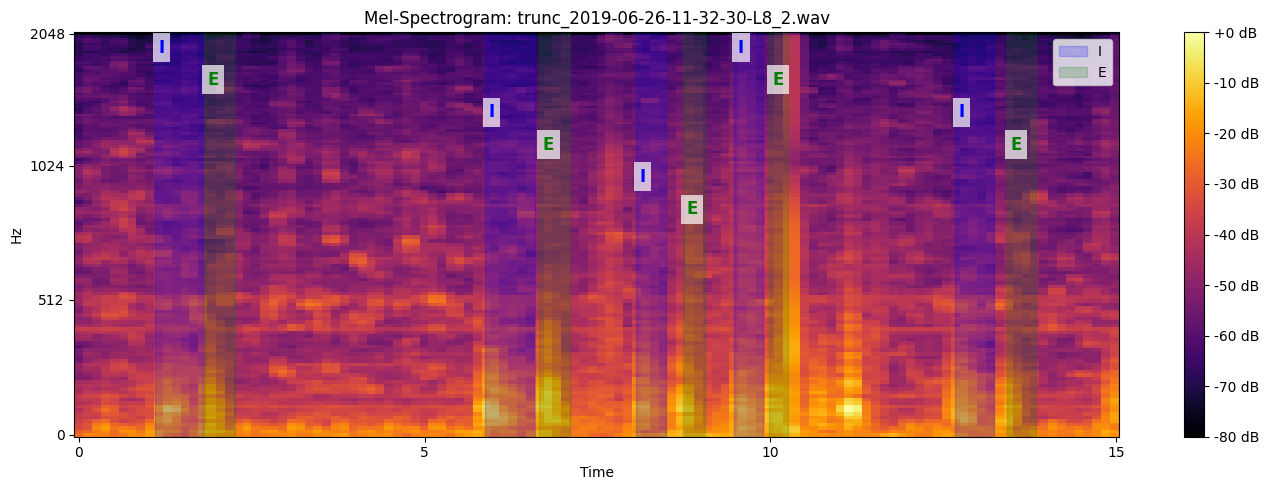

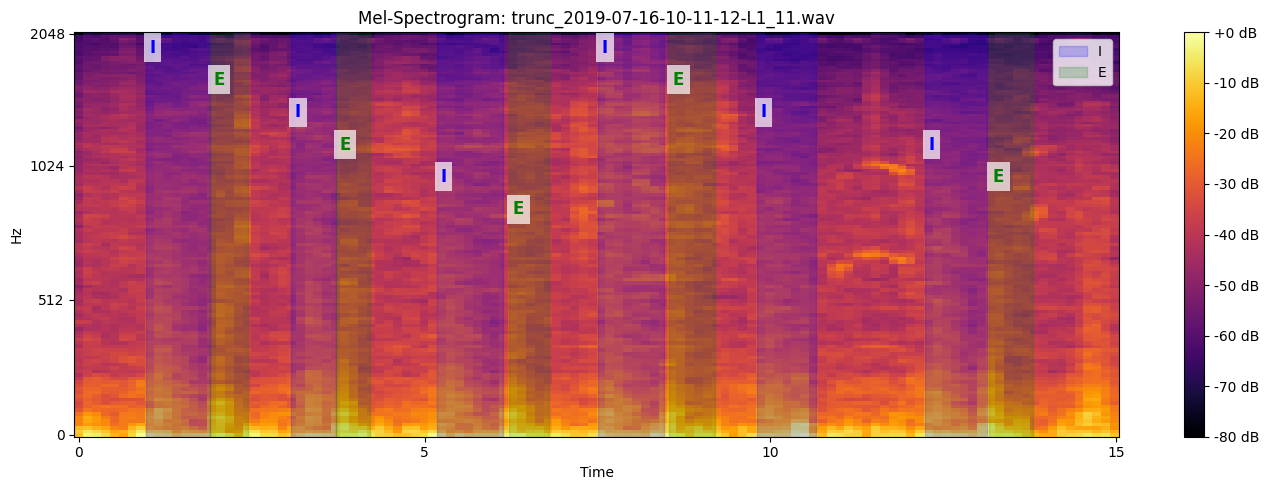

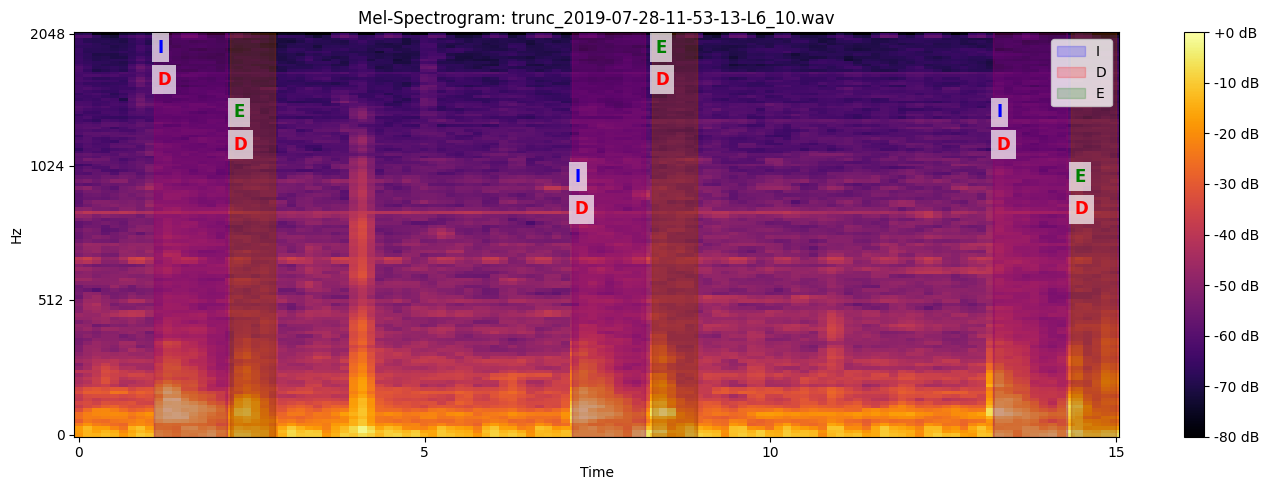

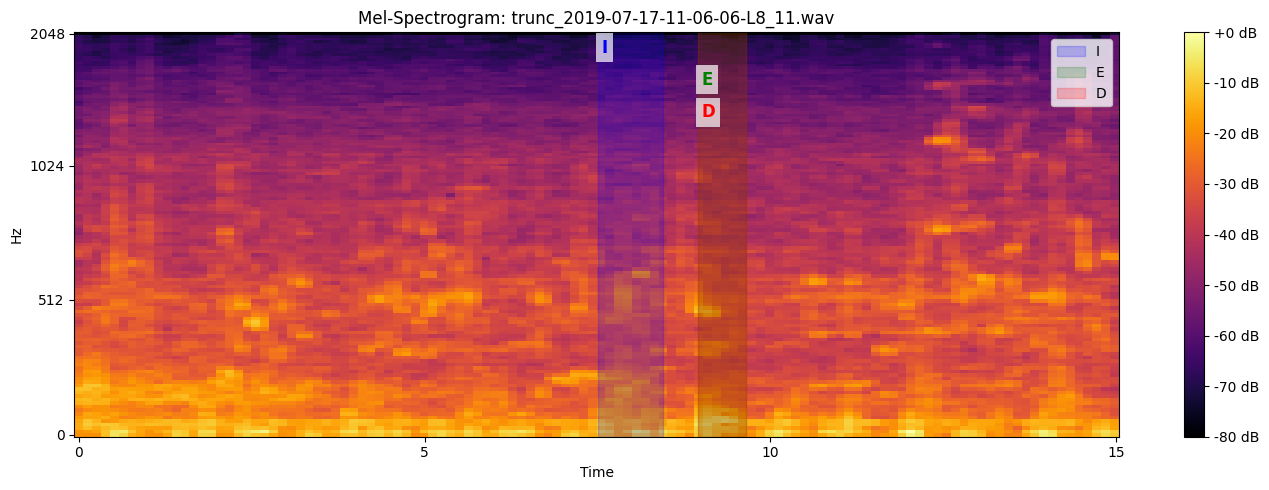

In [28]:
# Sample 10 files that contain at least one 'I' label
plot_samples_for_label('I', n_samples=10)

In [35]:
import random
import scipy.signal as signal
import IPython.display as ipd
import numpy as np
import librosa

# Define clinical lung sound frequency boundaries
LOWCUT = 100.0   # Filters out heavy heartbeats and low rumble
DESIRED_HIGHCUT = 2500.0 # Target high-frequency cut-off

def butter_bandpass(lowcut, highcut, fs, order=5):
    """Creates the bandpass filter coefficients with Nyquist safety checks."""
    nyq = 0.5 * fs
    
    # SAFETY CHECK: Ensure highcut is strictly less than the Nyquist frequency
    # We cap it at 99% of Nyquist to avoid the 'W < 1' error
    actual_highcut = min(highcut, nyq * 0.99)
    
    # Ensure lowcut is also valid (must be > 0 and < actual_highcut)
    actual_lowcut = max(lowcut, 1.0) 
    if actual_lowcut >= actual_highcut:
        actual_lowcut = actual_highcut * 0.1 # Fallback if audio is extremely low res

    low = actual_lowcut / nyq
    high = actual_highcut / nyq
    
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies the bandpass filter to the audio data."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y_filtered = signal.filtfilt(b, a, data)
    return y_filtered

# Select a random file
random_filename = random.choice(df['filename'].unique())
audio_path = os.path.join(train, random_filename)
print(f"--- Processing: {random_filename} ---")

# Load audio
y, sr = librosa.load(audio_path, sr=None)

# Calculate what the actual highcut will be for the print statement
actual_highcut = min(DESIRED_HIGHCUT, (sr * 0.5) * 0.99)

# Apply the filter to clean the audio
y_clean = bandpass_filter(y, LOWCUT, DESIRED_HIGHCUT, sr, order=4)

# Output playable widgets
print(f"Original Audio (Sampling Rate: {sr} Hz):")
ipd.display(ipd.Audio(y, rate=sr))

print(f"Cleaned Audio (Bandpass {LOWCUT} Hz - {actual_highcut:.1f} Hz):")
ipd.display(ipd.Audio(y_clean, rate=sr))

--- Processing: steth_20190722_16_26_18.wav ---
Original Audio (Sampling Rate: 4000 Hz):


Cleaned Audio (Bandpass 100.0 Hz - 1980.0 Hz):


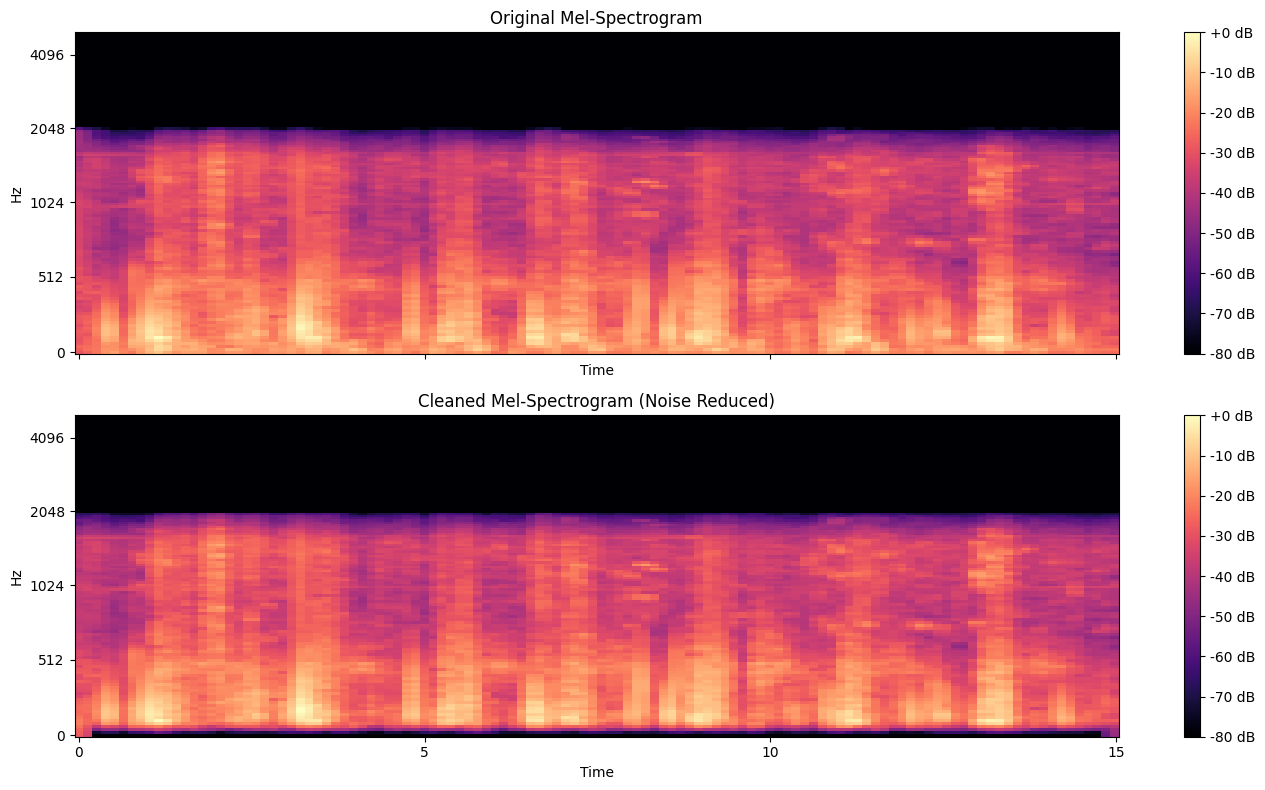

In [41]:
# Calculate Mel-spectrogram for the Original Audio
S_orig = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=5000)
S_orig_dB = librosa.power_to_db(S_orig, ref=np.max)

# Calculate Mel-spectrogram for the Cleaned Audio
S_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=5000)
S_clean_dB = librosa.power_to_db(S_clean, ref=np.max)

# Plot them side-by-side (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot Original
img1 = librosa.display.specshow(S_orig_dB, x_axis='time', y_axis='mel', sr=sr, fmax=5000, cmap='magma', ax=axes[0])
axes[0].set_title('Original Mel-Spectrogram')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

# Plot Cleaned
img2 = librosa.display.specshow(S_clean_dB, x_axis='time', y_axis='mel', sr=sr, fmax=5000, cmap='magma', ax=axes[1])
axes[1].set_title('Cleaned Mel-Spectrogram (Noise Reduced)')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

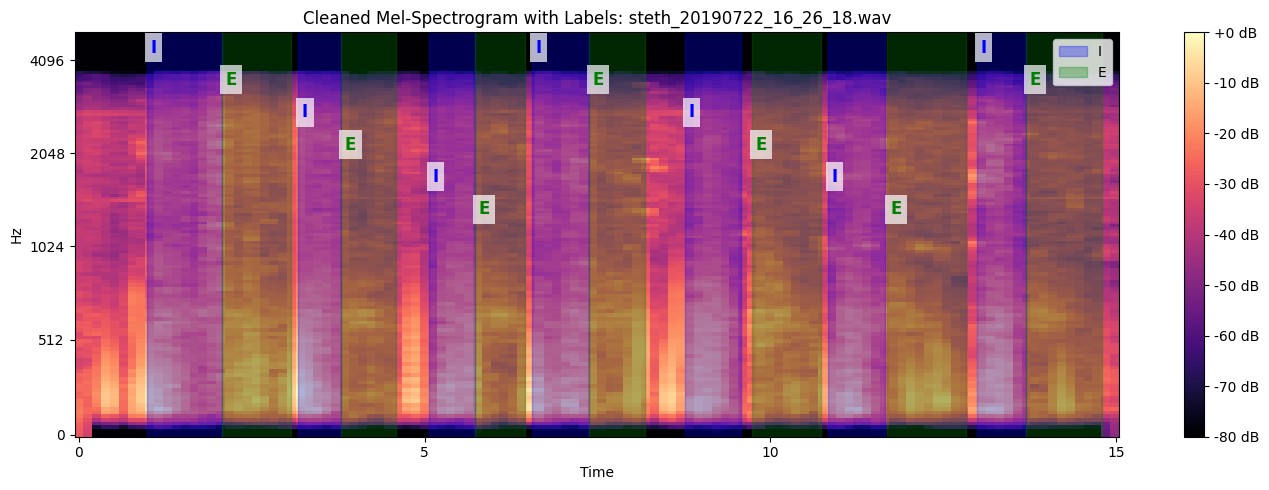

In [40]:
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_clean_dB, x_axis='time', y_axis='mel', sr=sr, fmax=5000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Cleaned Mel-Spectrogram with Labels: {random_filename}')

file_annotations = df[df['filename'] == random_filename]
height_offset = 0.95

# Iterate through the labels and plot them
for _, row in file_annotations.iterrows():
    start = row['start_time']
    end = row['end_time']
    lbl = row['label']
    color = COLOR_MAP.get(lbl, 'white')
    
    # Draw semi-transparent block
    plt.axvspan(start, end, color=color, alpha=0.3, label=lbl)
    
    # Add text annotation
    plt.text(start + 0.05, height_offset, lbl, color=color, fontsize=12, 
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
             transform=plt.gca().get_xaxis_transform())
    
    # Stagger heights to prevent overlap
    height_offset -= 0.08
    if height_offset < 0.5: 
        height_offset = 0.95 
        
# Organize the legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
if by_label:
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()
plt.show()

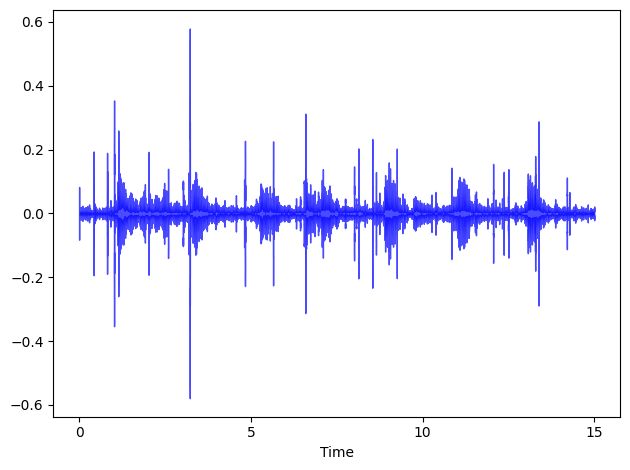

In [ ]:
# 1. Original Audio Waveform
librosa.display.waveshow(y, sr=sr, color='blue', alpha=0.7)
plt.tight_layout()
plt.show()

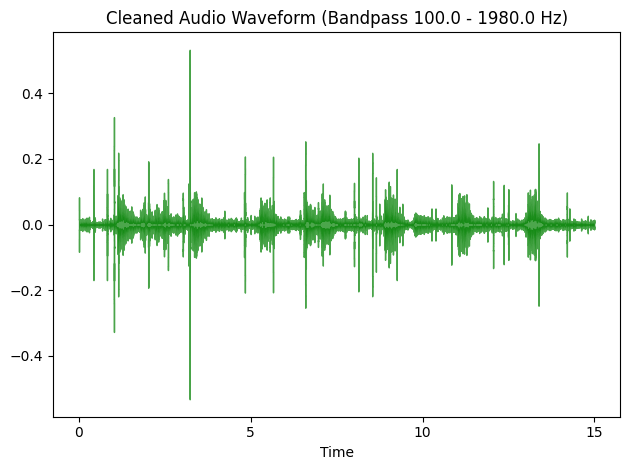

In [46]:
# 2. Cleaned Audio Waveform
# We use y_clean and the actual_highcut variable calculated in Cell 10
librosa.display.waveshow(y_clean, sr=sr, color='green', alpha=0.7)
plt.title(f'Cleaned Audio Waveform (Bandpass {LOWCUT} - {actual_highcut:.1f} Hz)')
plt.tight_layout()
plt.show()


In [48]:
%pip install noisereduce PyWavelets

  Using cached noisereduce-3.0.3-py3-none-any.whl.metadata (14 kB)
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.2 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 2.9/4.2 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 7.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 2/2 [noisereduce]

Note: you may need to restart the kernel to use updated packages.


In [54]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
import noisereduce as nr
import pywt
from scipy.signal import butter, filtfilt

# Target the specific audio file
AUDIO_FILE = "C:\\Spectrolung\\RAW_Datasets\\HF_lung_V1_RAW\\train\\steth_20180814_09_58_36.wav"
TARGET_SR = 16000
N_MELS = 64
OPTIMAL_FMAX = 2048

# Load the raw audio
print("Loading raw audio...")
y_raw, sr = librosa.load(AUDIO_FILE, sr=TARGET_SR)

# Helper function to plot and play audio side-by-side
def compare_processing(y_old, y_new, sr, step_name):
    print(f"\n{'='*60}")
    print(f" STEP: {step_name}")
    print(f"{'='*60}")
    
    # 1. Playable Audio Widgets
    print("\n🎧 Audio BEFORE this step:")
    display(Audio(data=y_old, rate=sr))
    
    print("\n🎧 Audio AFTER this step:")
    display(Audio(data=y_new, rate=sr))
    
    # 2. Calculate Mel Spectrograms
    mel_old = librosa.feature.melspectrogram(y=y_old, sr=sr, n_mels=N_MELS, fmax=OPTIMAL_FMAX)
    mel_old_db = librosa.power_to_db(mel_old, ref=np.max)
    
    mel_new = librosa.feature.melspectrogram(y=y_new, sr=sr, n_mels=N_MELS, fmax=OPTIMAL_FMAX)
    mel_new_db = librosa.power_to_db(mel_new, ref=np.max)
    
    # 3. Plotting side-by-side
    fig, ax = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
    
    # Waveforms
    librosa.display.waveshow(y_old, sr=sr, ax=ax[0, 0], color='#024b80', alpha=0.8)
    ax[0, 0].set_title(f"Waveform BEFORE")
    ax[0, 0].set_ylabel("Amplitude")
    
    librosa.display.waveshow(y_new, sr=sr, ax=ax[0, 1], color='#2ca02c', alpha=0.8)
    ax[0, 1].set_title(f"Waveform AFTER")
    
    # Spectrograms
    librosa.display.specshow(mel_old_db, sr=sr, x_axis='time', y_axis='mel', fmax=OPTIMAL_FMAX, cmap='inferno', ax=ax[1, 0])
    ax[1, 0].set_title(f"Mel-Spectrogram BEFORE")
    
    librosa.display.specshow(mel_new_db, sr=sr, x_axis='time', y_axis='mel', fmax=OPTIMAL_FMAX, cmap='inferno', ax=ax[1, 1])
    ax[1, 1].set_title(f"Mel-Spectrogram AFTER")
    
    plt.tight_layout()
    plt.show()

print("Setup complete. Ready for Step 1.")

Loading raw audio...
Setup complete. Ready for Step 1.


Applying Spectral Gating...

 STEP: 1. Spectral Gating (Ambient Hum Removal)

🎧 Audio BEFORE this step:



🎧 Audio AFTER this step:


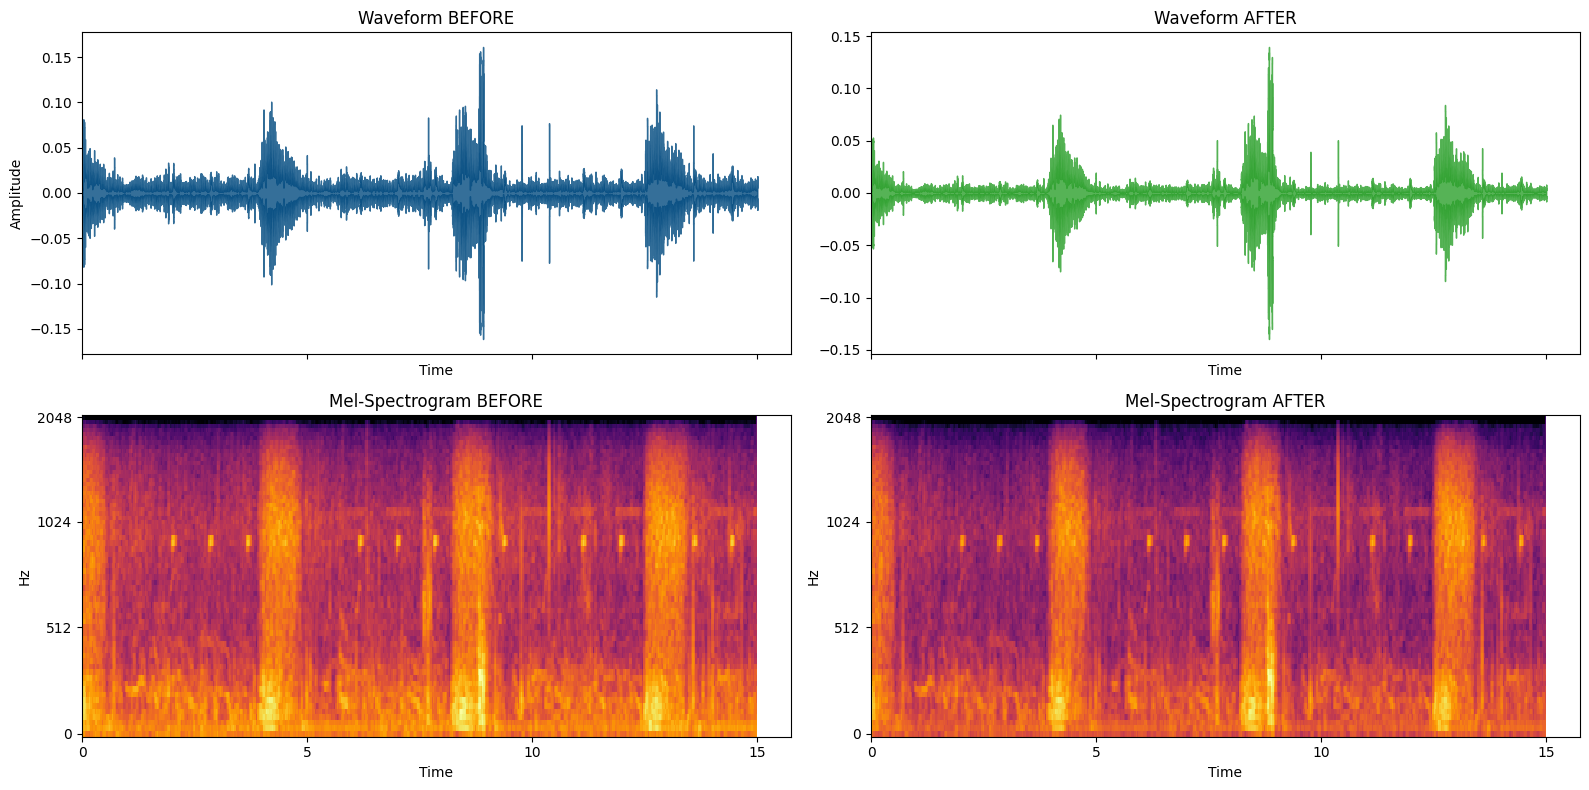

In [58]:
# Spectral Gating models the stationary background hum (like A/C or wind) 
# and mathematically subtracts it from the entire track.
# prop_decrease=0.8 means we remove 80% of the calculated noise to prevent robotic distortion.

print("Applying Spectral Gating...")
y_gated = nr.reduce_noise(y=y_raw, sr=sr, stationary=True, prop_decrease=0.5)

compare_processing(y_raw, y_gated, sr, "1. Spectral Gating (Ambient Hum Removal)")

Applying Gentle Heart Sound Suppression...

 STEP: 2. Gentle High-Pass (Heart Sound Suppression)

🎧 Audio BEFORE this step:



🎧 Audio AFTER this step:


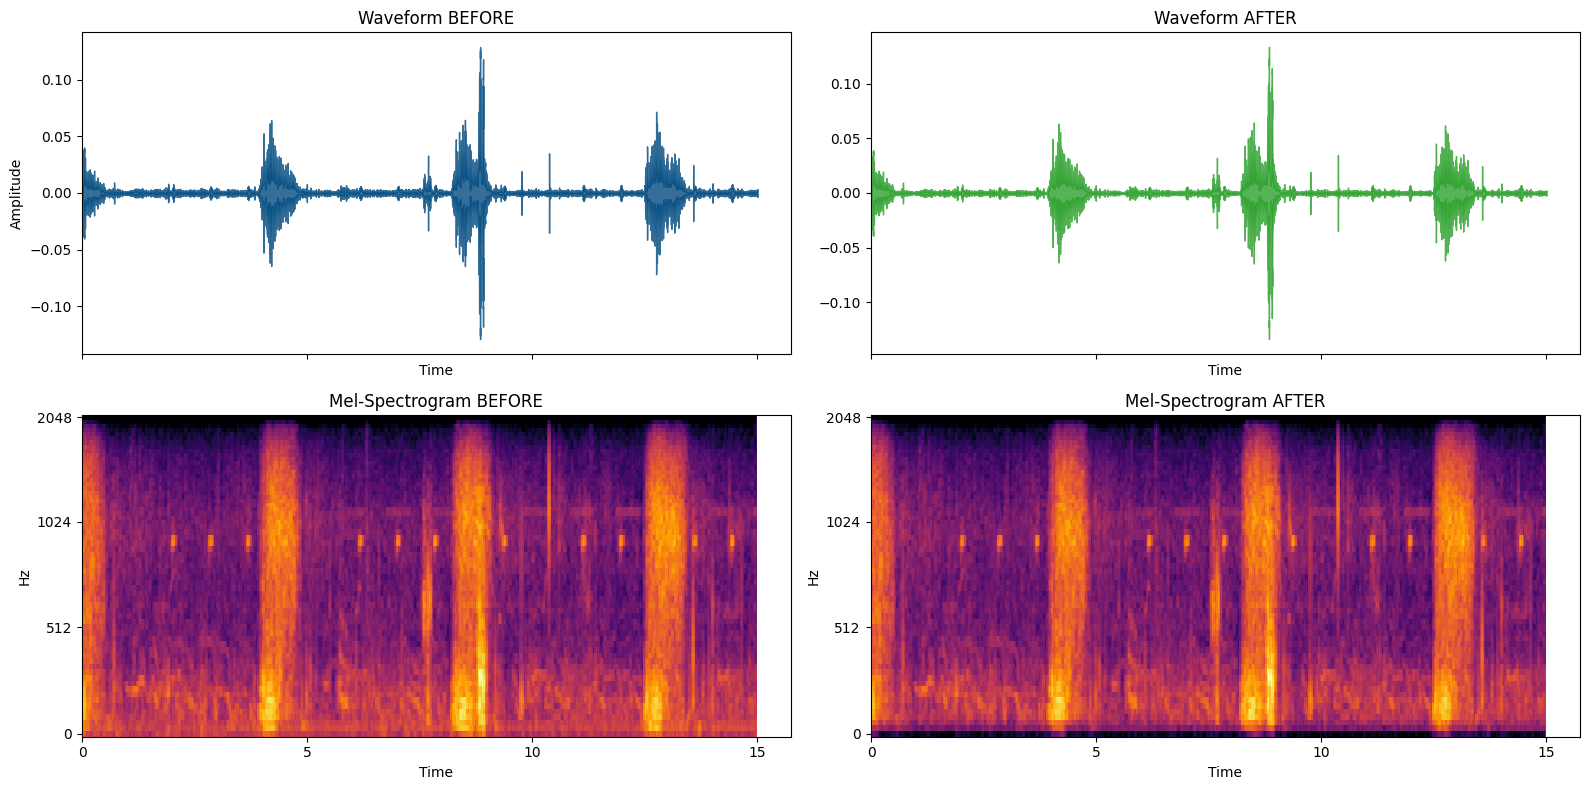

In [56]:
# Heartbeats exist mostly between 20Hz and 80Hz. 
# Instead of a harsh global filter that cuts out lung sounds, we use a gentle 
# high-pass filter specifically targeted at rolling off the heavy heart 'thuds'.

def gentle_highpass(data, sr, cutoff=80.0, order=3):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

print("Applying Gentle Heart Sound Suppression...")
y_no_heart = gentle_highpass(y_gated, sr, cutoff=80.0)

compare_processing(y_gated, y_no_heart, sr, "2. Gentle High-Pass (Heart Sound Suppression)")


Applying Wavelet Denoising...

 STEP: 3. Wavelet Denoising (Friction/Transient Spikes)

🎧 Audio BEFORE this step:



🎧 Audio AFTER this step:


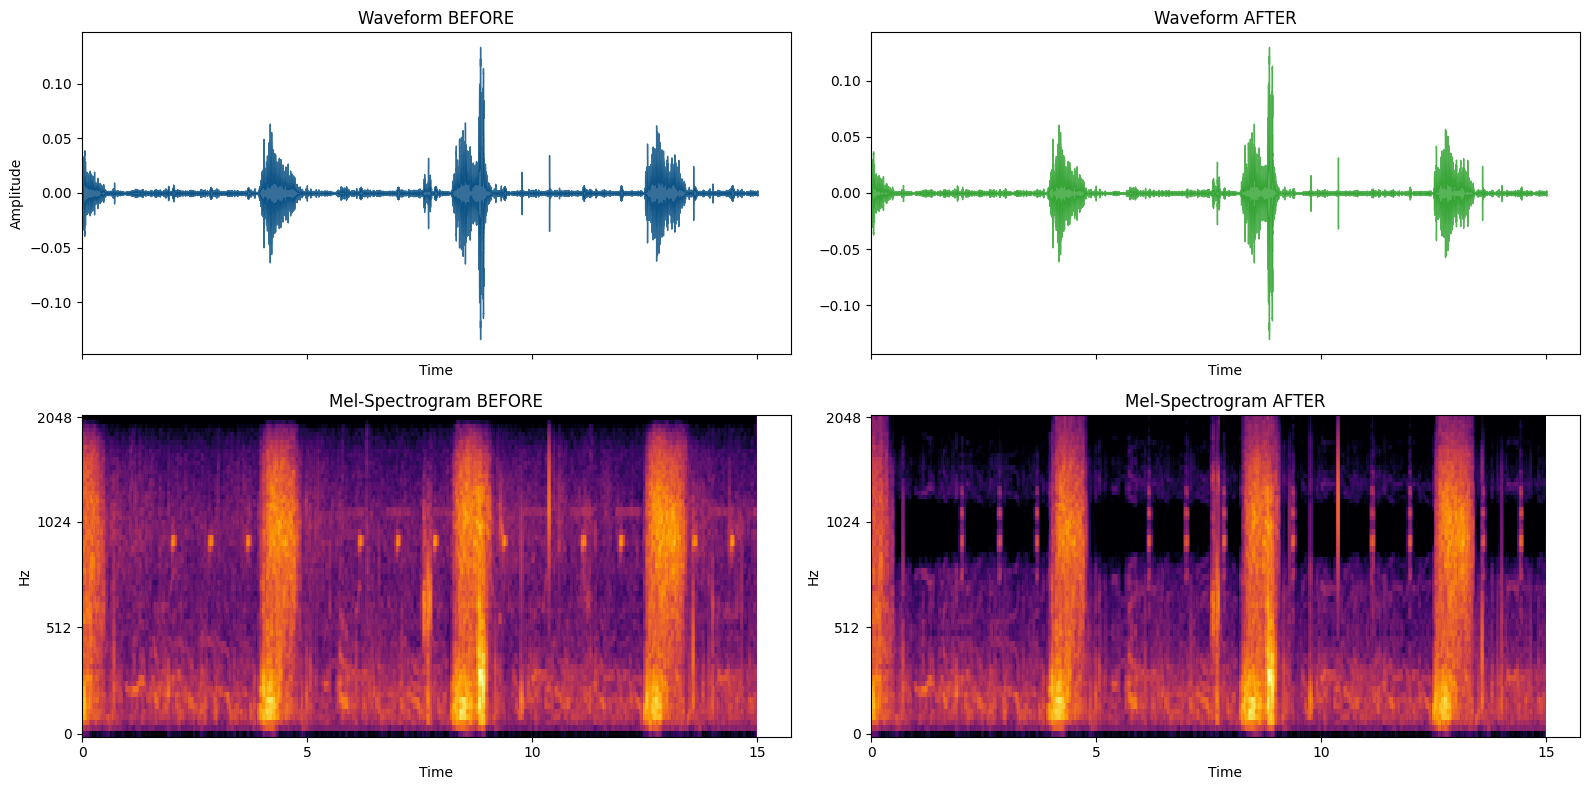

In [57]:
# Wavelets excel at finding short, sudden transient spikes (like a stethoscope 
# scratching against skin) and softening them without destroying the actual breath cycle.

def wavelet_denoise(data, wavelet='db4', level=4):
    # 1. Decompose the audio into wavelet coefficients
    coeffs = pywt.wavedec(data, wavelet, mode='per', level=level)
    
    # 2. Calculate a noise threshold based on the median absolute deviation
    sigma = (1/0.6745) * np.median(np.abs(coeffs[-level] - np.median(coeffs[-level])))
    threshold = sigma * np.sqrt(2 * np.log(len(data)))
    
    # 3. Apply soft thresholding to squash the friction spikes
    new_coeffs = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]
    
    # 4. Reconstruct the cleaned audio
    return pywt.waverec(new_coeffs, wavelet, mode='per')

print("Applying Wavelet Denoising...")
y_wavelet = wavelet_denoise(y_no_heart)

compare_processing(y_no_heart, y_wavelet, sr, "3. Wavelet Denoising (Friction/Transient Spikes)")